<a href="https://colab.research.google.com/github/PedroTapia98/Anallysis-DataS-Tiendas/blob/main/NubeDePuntos_Nivel_UTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install open3d numpy

In [ ]:
pip install pye57

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 50.7 MB/s eta 0:00:00



--- RESULTADOS GENERALES ---
Cota recomendada: 2574.426 m
Tolerancia: ±0.168 m
Variación total: 0.337 m
Calidad global: IRREGULAR


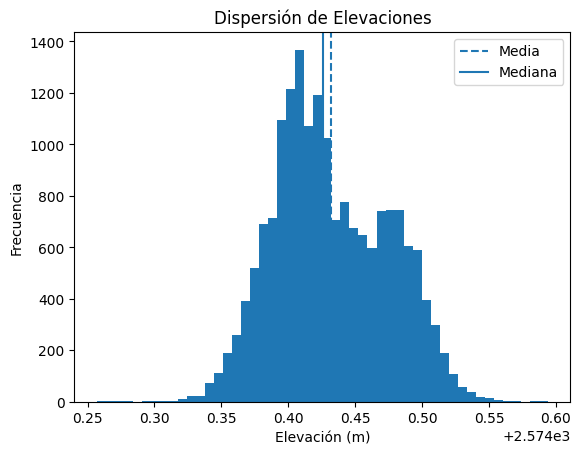

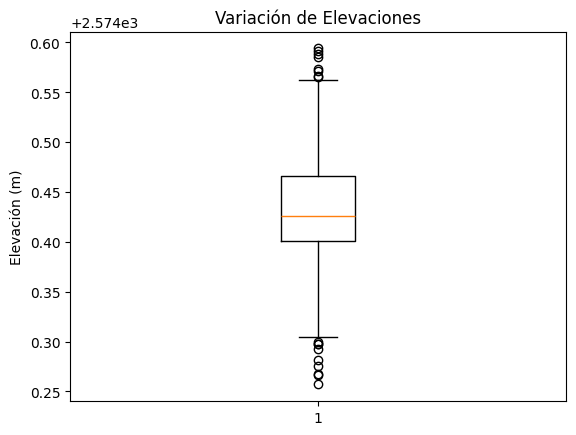

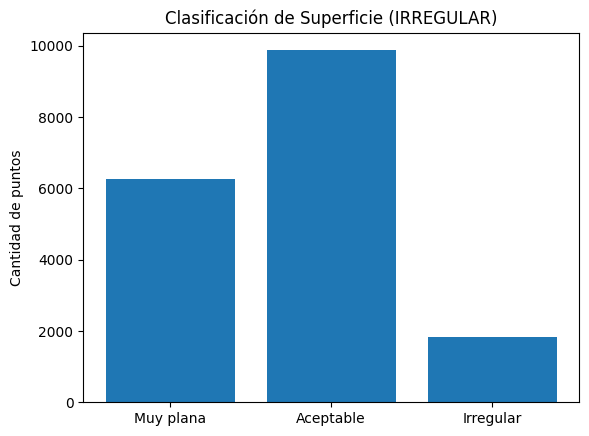

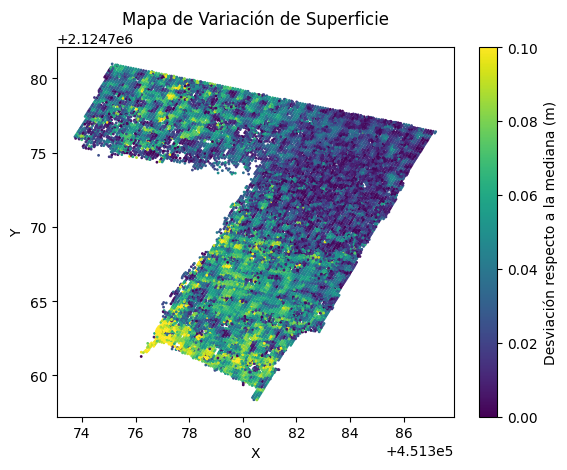


--- REPORTE FINAL ---
Nivel de plataforma: 2574.426 m
Condición: IRREGULAR
Tolerancia: ±0.168 m


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 📂 CARGAR PTS
# -----------------------
archivo = "/content/sample_data/nivles0.pts"
points = np.loadtxt(archivo, skiprows=1)

X = points[:, 0]
Y = points[:, 1]
Z = points[:, 2]

# -----------------------
# 📊 ESTADÍSTICOS BASE
# -----------------------
mean_z = np.mean(Z)
median_z = np.median(Z)
min_z = np.min(Z)
max_z = np.max(Z)

variacion = max_z - min_z

# -----------------------
# 🎯 COTA RECOMENDADA
# -----------------------
cota_recomendada = round(median_z, 3)

# Tolerancia (± mitad del rango)
tolerancia = round(variacion / 2, 3)

print("\n--- RESULTADOS GENERALES ---")
print(f"Cota recomendada: {cota_recomendada} m")
print(f"Tolerancia: ±{tolerancia} m")
print(f"Variación total: {variacion:.3f} m")

# -----------------------
# 🟢 CLASIFICACIÓN GLOBAL
# -----------------------
if variacion < 0.10:
    calidad = "MUY PLANA"
elif variacion < 0.20:
    calidad = "ACEPTABLE"
else:
    calidad = "IRREGULAR"

print(f"Calidad global: {calidad}")

# -----------------------
# 📊 HISTOGRAMA
# -----------------------
plt.figure()
plt.hist(Z, bins=50)
plt.axvline(mean_z, linestyle='--', label='Media')
plt.axvline(median_z, linestyle='-', label='Mediana')
plt.legend()
plt.title("Dispersión de Elevaciones")
plt.xlabel("Elevación (m)")
plt.ylabel("Frecuencia")
plt.show()

# -----------------------
# 📦 BOXPLOT
# -----------------------
plt.figure()
plt.boxplot(Z)
plt.title("Variación de Elevaciones")
plt.ylabel("Elevación (m)")
plt.show()

# -----------------------
# 📊 BARRAS DE CLASIFICACIÓN
# -----------------------
clasificacion = []
diffs = []

for z in Z:
    diff = abs(z - median_z)
    diffs.append(diff)

    if diff < 0.02:
        clasificacion.append(0)
    elif diff < 0.07:
        clasificacion.append(1)
    else:
        clasificacion.append(2)

clasificacion = np.array(clasificacion)
diffs = np.array(diffs)

muy_plana = np.sum(clasificacion == 0)
aceptable = np.sum(clasificacion == 1)
irregular = np.sum(clasificacion == 2)

labels = ["Muy plana", "Aceptable", "Irregular"]
valores = [muy_plana, aceptable, irregular]

plt.figure()
plt.bar(labels, valores)
plt.title(f"Clasificación de Superficie ({calidad})")
plt.ylabel("Cantidad de puntos")
plt.show()

# -----------------------
# 🌈 MAPA DE VARIACIÓN
# -----------------------
plt.figure()
scatter = plt.scatter(X, Y, c=diffs, s=1, vmin=0, vmax=0.10)

plt.title("Mapa de Variación de Superficie")
plt.xlabel("X")
plt.ylabel("Y")

cbar = plt.colorbar(scatter)
cbar.set_label("Desviación respecto a la mediana (m)")

plt.show()

# -----------------------
# 🏗️ REPORTE FINAL
# -----------------------
print("\n--- REPORTE FINAL ---")
print(f"Nivel de plataforma: {cota_recomendada} m")
print(f"Condición: {calidad}")
print(f"Tolerancia: ±{tolerancia} m")

Total puntos: 780
Puntos después de filtro: 772

--- RESULTADOS ---
Cota recomendada: 2574.458 m
Tolerancia: ±0.073 m
Variación: 0.146 m
Condición: ACEPTABLE


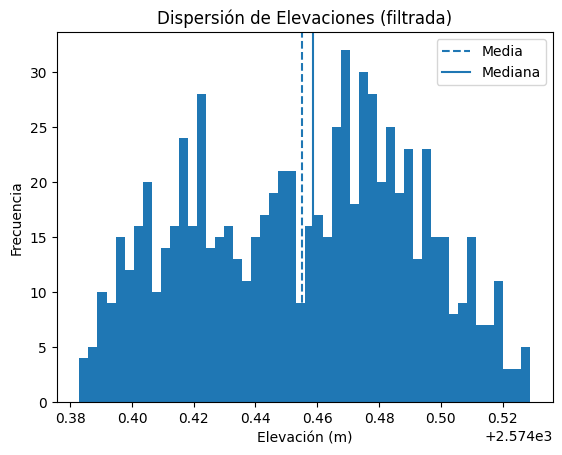

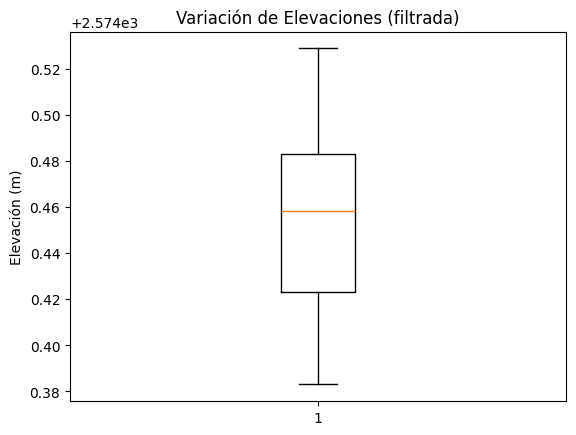

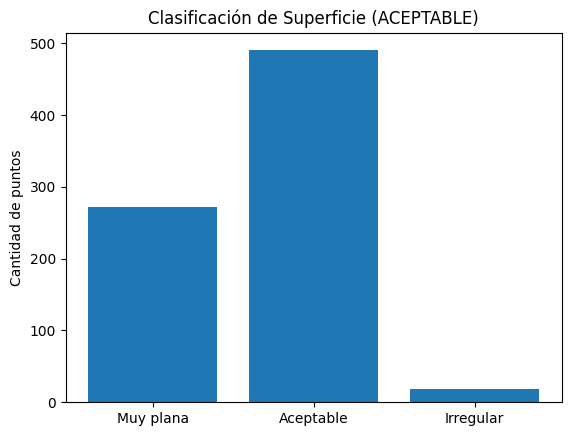

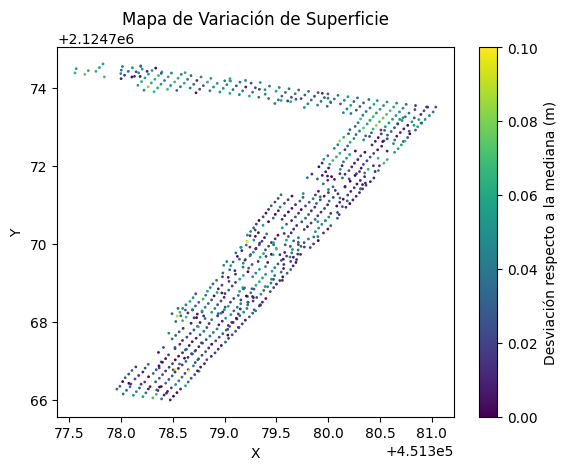


--- REPORTE FINAL ---
Nivel de plataforma: 2574.458 m
Condición: ACEPTABLE
Tolerancia: ±0.073 m


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 📂 CARGAR PTS
# -----------------------
archivo = "/content/drive/MyDrive/Nivel0PuntosCEdificio.pts"
points = np.loadtxt(archivo, skiprows=1)

X = points[:, 0]
Y = points[:, 1]
Z = points[:, 2]

print("Total puntos:", len(Z))

# -----------------------
# 🧹 FILTRO ROBUSTO (DESVIACIÓN ESTÁNDAR)
# -----------------------
mean_z = np.mean(Z)
std_z = np.std(Z)

z_filtrado = Z[
    (Z > mean_z - 2 * std_z) &
    (Z < mean_z + 2 * std_z)
]

print("Puntos después de filtro:", len(z_filtrado))

# -----------------------
# 📊 ESTADÍSTICOS
# -----------------------
median_z = np.median(z_filtrado)
mean_z_filtrado = np.mean(z_filtrado)

min_z = np.min(z_filtrado)
max_z = np.max(z_filtrado)

variacion = max_z - min_z

# -----------------------
# 🎯 COTA RECOMENDADA
# -----------------------
cota_recomendada = round(median_z, 3)
tolerancia = round(variacion / 2, 3)

# -----------------------
# 🟢 CLASIFICACIÓN GLOBAL (AJUSTADA)
# -----------------------
if variacion < 0.10:
    calidad = "MUY PLANA"
elif variacion < 0.20:
    calidad = "ACEPTABLE"
else:
    calidad = "IRREGULAR"

print("\n--- RESULTADOS ---")
print(f"Cota recomendada: {cota_recomendada} m")
print(f"Tolerancia: ±{tolerancia} m")
print(f"Variación: {variacion:.3f} m")
print(f"Condición: {calidad}")

# -----------------------
# 📊 HISTOGRAMA
# -----------------------
plt.figure()
plt.hist(z_filtrado, bins=50)
plt.axvline(mean_z_filtrado, linestyle='--', label='Media')
plt.axvline(median_z, linestyle='-', label='Mediana')
plt.legend()
plt.title("Dispersión de Elevaciones (filtrada)")
plt.xlabel("Elevación (m)")
plt.ylabel("Frecuencia")
plt.show()

# -----------------------
# 📦 BOXPLOT
# -----------------------
plt.figure()
plt.boxplot(z_filtrado)
plt.title("Variación de Elevaciones (filtrada)")
plt.ylabel("Elevación (m)")
plt.show()

# -----------------------
# 🟢 CLASIFICACIÓN POR PUNTO
# -----------------------
clasificacion = []
diffs = []

for z in Z:
    diff = abs(z - median_z)
    diffs.append(diff)

    if diff < 0.02:
        clasificacion.append(0)  # muy plana
    elif diff < 0.07:
        clasificacion.append(1)  # aceptable
    else:
        clasificacion.append(2)  # irregular

clasificacion = np.array(clasificacion)
diffs = np.array(diffs)

# Conteo
muy_plana = np.sum(clasificacion == 0)
aceptable = np.sum(clasificacion == 1)
irregular = np.sum(clasificacion == 2)

# -----------------------
# 📊 GRÁFICA DE BARRAS
# -----------------------
labels = ["Muy plana", "Aceptable", "Irregular"]
valores = [muy_plana, aceptable, irregular]

plt.figure()
plt.bar(labels, valores)
plt.title(f"Clasificación de Superficie ({calidad})")
plt.ylabel("Cantidad de puntos")
plt.show()

# -----------------------
# 🌈 MAPA DE VARIACIÓN
# -----------------------
plt.figure()
scatter = plt.scatter(X, Y, c=diffs, s=1, vmin=0, vmax=0.10)

plt.title("Mapa de Variación de Superficie")
plt.xlabel("X")
plt.ylabel("Y")

cbar = plt.colorbar(scatter)
cbar.set_label("Desviación respecto a la mediana (m)")

plt.show()

# -----------------------
# 🏗️ REPORTE FINAL
# -----------------------
print("\n--- REPORTE FINAL ---")
print(f"Nivel de plataforma: {cota_recomendada} m")
print(f"Condición: {calidad}")
print(f"Tolerancia: ±{tolerancia} m")

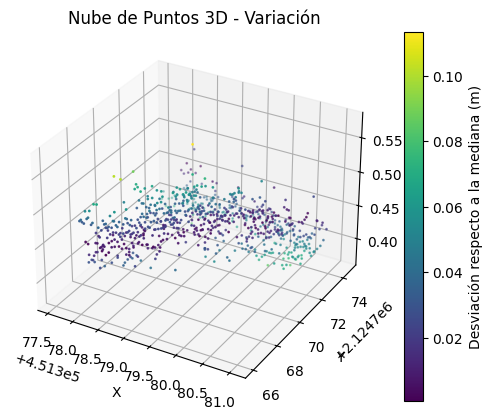

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Ya tienes X, Y, Z, diffs

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(X, Y, Z, c=diffs, s=1)

ax.set_title("Nube de Puntos 3D - Variación")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

cbar = plt.colorbar(sc)
cbar.set_label("Desviación respecto a la mediana (m)")

plt.show()

In [ ]:
!pip install open3d

In [ ]:
!pip install plotly

In [5]:
import numpy as np
import pandas as pd
import plotly.express as px

# Cargar nube
points = np.loadtxt("/content/drive/MyDrive/Nivel0PuntosCEdificio.pts", skiprows=1)

X = points[:,0]
Y = points[:,1]
Z = points[:,2]

# Variación
median_z = np.median(Z)
diffs = np.abs(Z - median_z)

# DataFrame
df = pd.DataFrame({
    "X": X,
    "Y": Y,
    "Z": Z,
    "Variacion": diffs
})

# Gráfica 3D
fig = px.scatter_3d(
    df,
    x="X",
    y="Y",
    z="Z",
    color="Variacion",
    title="Nube 3D - Variación de Superficie"
)

fig.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Total puntos nube: 780
Longitud eje: 17.07 m


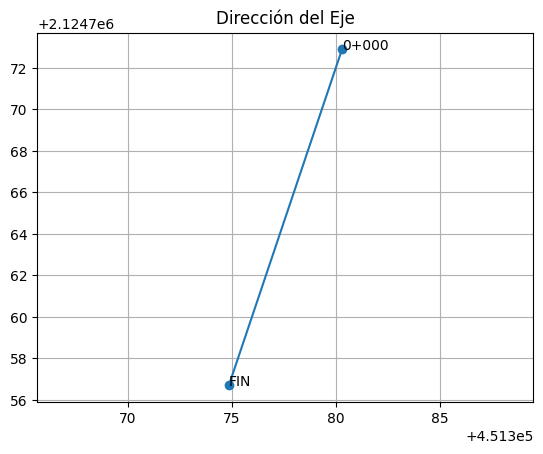


Archivo generado: cadenamiento_con_z.csv


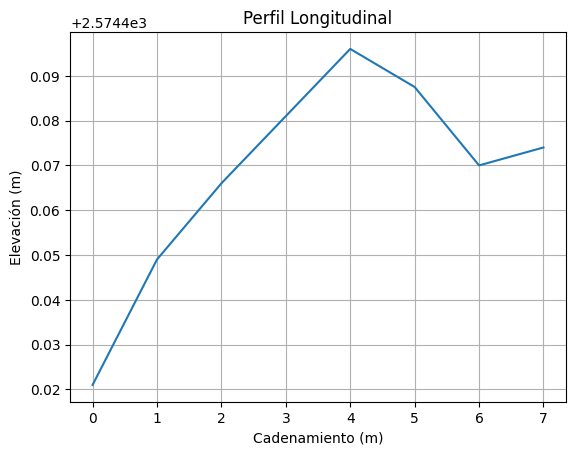

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 📂 CARGAR NUBE (.PTS)
# -----------------------
archivo = "/content/drive/MyDrive/Nivel0PuntosCEdificio.pts"
points = np.loadtxt(archivo, skiprows=1)

X = points[:, 0]
Y = points[:, 1]
Z = points[:, 2]

print("Total puntos nube:", len(Z))

# -----------------------
# 📍 DEFINIR EJE (TÚ CONTROLAS ESTO)
# -----------------------
x_inicio, y_inicio = 451380.303, 2124772.885   # 0+000
x_fin, y_fin = 451374.854, 2124756.704         # FIN

# -----------------------
# 📏 VECTOR DIRECCIÓN
# -----------------------
dx = x_fin - x_inicio
dy = y_fin - y_inicio
longitud = np.sqrt(dx**2 + dy**2)

ux = dx / longitud
uy = dy / longitud

# Vector perpendicular (IZQ)
px = -uy
py = ux

print("Longitud eje:", round(longitud,2), "m")

# -----------------------
# 👀 VALIDAR DIRECCIÓN
# -----------------------
plt.figure()
plt.plot([x_inicio, x_fin], [y_inicio, y_fin], marker='o')
plt.text(x_inicio, y_inicio, "0+000")
plt.text(x_fin, y_fin, "FIN")
plt.title("Dirección del Eje")
plt.axis('equal')
plt.grid()
plt.show()

# -----------------------
# 🎯 FUNCIÓN Z LOCAL (MEDIANA)
# -----------------------
def obtener_z_local(x, y, X, Y, Z, radio=0.5):
    dist = np.sqrt((X - x)**2 + (Y - y)**2)
    mask = dist < radio
    z_local = Z[mask]

    if len(z_local) == 0:
        return np.nan

    return np.median(z_local)

# -----------------------
# 📍 GENERAR CADENAMIENTO
# -----------------------
distancias = np.arange(0, longitud, 1)

data = []

for d in distancias:
    # Punto sobre eje
    x = x_inicio + ux * d
    y = y_inicio + uy * d

    # 🔥 Z correcta (mediana local)
    z = obtener_z_local(x, y, X, Y, Z, radio=0.5)

    # offsets ±0.10 m
    x_izq = x + px * 0.10
    y_izq = y + py * 0.10
    z_izq = obtener_z_local(x_izq, y_izq, X, Y, Z, radio=0.5)

    x_der = x - px * 0.10
    y_der = y - py * 0.10
    z_der = obtener_z_local(x_der, y_der, X, Y, Z, radio=0.5)

    # Guardar
    data.append([d, x_izq, y_izq, z_izq, "IZQ"])
    data.append([d, x, y, z, "CENTRO"])
    data.append([d, x_der, y_der, z_der, "DER"])

# -----------------------
# 💾 EXPORTAR CSV
# -----------------------
df = pd.DataFrame(data, columns=["Cadenamiento", "X", "Y", "Z", "Tipo"])

df.to_csv("cadenamiento_con_z.csv", index=False)

print("\nArchivo generado: cadenamiento_con_z.csv")

# -----------------------
# 📊 PERFIL LONGITUDINAL (EXTRA 🔥)
# -----------------------
df_centro = df[df["Tipo"] == "CENTRO"]

plt.figure()
plt.plot(df_centro["Cadenamiento"], df_centro["Z"])
plt.title("Perfil Longitudinal")
plt.xlabel("Cadenamiento (m)")
plt.ylabel("Elevación (m)")
plt.grid()
plt.show()

In [2]:
!pip install ezdxf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 51.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import ezdxf

# -----------------------
# 📂 CARGAR CSV
# -----------------------
df = pd.read_csv("/content/cadenamiento_con_z.csv")

# -----------------------
# 📐 CREAR DXF
# -----------------------
doc = ezdxf.new()
msp = doc.modelspace()

# -----------------------
# 📍 AGREGAR PUNTOS
# -----------------------
for _, row in df.iterrows():
    x = row["X"]
    y = row["Y"]
    z = row["Z"]

    # Punto 3D
    msp.add_point((x, y, z))

# -----------------------
# 💾 GUARDAR
# -----------------------
doc.saveas("puntos_cadenamiento.dxf")

print("DXF generado: puntos_cadenamiento.dxf")

DXF generado: puntos_cadenamiento.dxf
